# Week 13 — Learn PINNs through a deep-cavity case

Start with the retained Re1000, D/W=2.2 field, then build and train a small CPU PINN. The older D=1 and D=2 cases remain as secondary research audits.

[Open in Colab](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week13/W13_Rectangular_Cavity_PINN_Research.ipynb)

<!-- MIE690A article-aligned validation v4 -->

In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete public evidence tree. Locally it is a no-op.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root)],
            check=True,
        )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week13"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab evidence ready:", _flowmllab_root)


In [2]:
from pathlib import Path
import hashlib, json
import matplotlib.pyplot as plt
import numpy as np

def find_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate/'qa/WEEK13_PINN_MATRIX_PROTOCOL.md').is_file(): return candidate
    raise FileNotFoundError('Run inside a complete FlowMLLab checkout')

ROOT=find_root(); RESULT=ROOT/'results/week13_rectangular_pinn'
CASES=[(100,1),(400,1),(100,2),(400,2)]
print('FlowMLLab root:', ROOT)


FlowMLLab root: C:\Users\roohie\OneDrive - University of Massachusetts\Documents\ChatGPT\FlowMLLAB\.release-week13-15


## Main case: a deep cavity, Re=1000 and D/W=2.2

This retained author-model field is evaluated from **restart-55118.ckpt**, on
a 301-by-661 physical grid. Follow the data checks and regenerate the figures
below before inspecting the shorter training exercise. The two examples use
different networks and parameter settings; the short CPU model does not
reproduce this checkpoint.

The supplied export includes u, v, p and derived streamfunction/vorticity, but
not model weights or matching CFD fields. A separately recovered continuation
history ends at checkpoint 65711, not this field checkpoint. The export therefore
supports field inspection, not a new claim of final optimizer convergence or
independent CFD validation. Streamfunction was integrated from u; extrema are
candidate vortex centres. Re-run residuals from the actual model before
interpreting finite-difference divergence as its autodifferentiated residual.

Checkpoint: /project/pi_roohie_umass_edu/FlowMLLab_chris_deep_tf_20260913/training/model/restart-55118.ckpt
{'FD_divergence_max_full': 4.325564732506521, 'FD_divergence_max_outside_top_corner_boxes': 0.13450734546737486, 'FD_divergence_RMS_full': 0.022060685988018164}


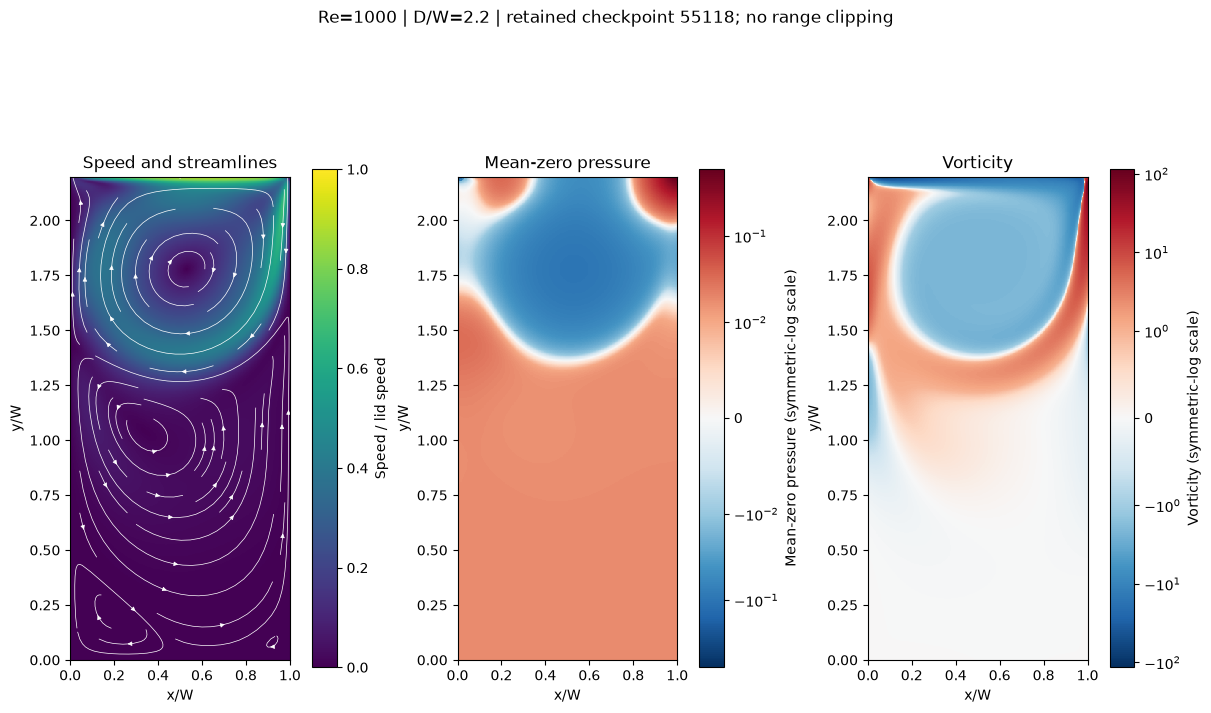

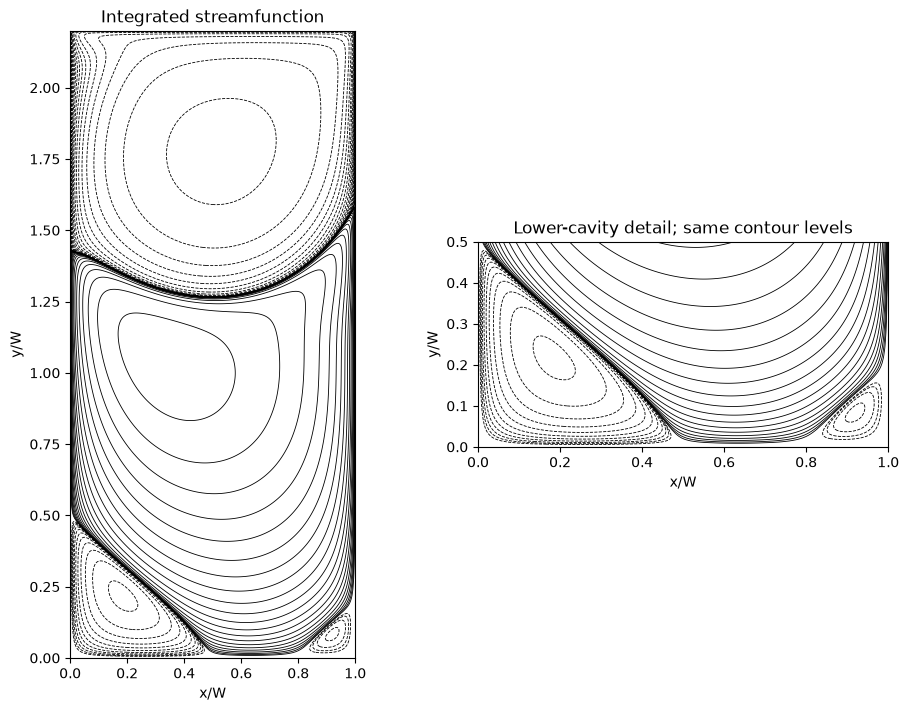

In [3]:
from scipy.integrate import cumulative_trapezoid
from matplotlib.colors import SymLogNorm
deep_dir=ROOT/'data/week13_deep_cavity'
deep_manifest=json.loads((deep_dir/'manifest.json').read_text())
for filename,digest in deep_manifest['files'].items():
    assert hashlib.sha256((deep_dir/filename).read_bytes()).hexdigest()==digest
deep_audit=json.loads((deep_dir/'audit.json').read_text())
assert deep_audit['case']=={'Re':1000.,'depth_over_width':2.2,'tri':0.}
with np.load(deep_dir/'field.npz',allow_pickle=False) as archive:
    deep={key:archive[key].copy() for key in archive.files}
x,y=deep['x'],deep['y']; u,v,p=deep['u'],deep['v'],deep['p']
assert u.shape==v.shape==p.shape==(661,301)
assert all(np.isfinite(a).all() for a in deep.values())
assert np.all(np.diff(x)>0) and np.all(np.diff(y)>0)
np.testing.assert_allclose([x[0],x[-1],y[0],y[-1]],[0,1,0,2.2])
psi=cumulative_trapezoid(u,y,axis=0,initial=0.)
omega=np.gradient(v,x,axis=1,edge_order=2)-np.gradient(u,y,axis=0,edge_order=2)
div=np.gradient(u,x,axis=1,edge_order=2)+np.gradient(v,y,axis=0,edge_order=2)
np.testing.assert_allclose(psi,deep['psi'],atol=1e-12)
np.testing.assert_allclose(omega,deep['omega'],atol=1e-10)
np.testing.assert_allclose(abs(div).max(),deep_audit['max_abs_divergence_fd'],rtol=1e-10)
for edge in [np.hypot(u[0],v[0]),np.hypot(u[:,0],v[:,0]),np.hypot(u[:,-1],v[:,-1])]:
    assert edge.max()<1e-10
XX,YY=np.meshgrid(x,y)
away=~(((XX<.1)|(XX>.9))&(YY>2.1))
print('Checkpoint:',deep_audit['checkpoint'])
print({'FD_divergence_max_full':float(abs(div).max()),
       'FD_divergence_max_outside_top_corner_boxes':float(abs(div[away]).max()),
       'FD_divergence_RMS_full':float(np.sqrt(np.mean(div**2)))})
# Remove the physical-area-weighted pressure gauge, not an arbitrary point value.
integral=lambda a:np.trapezoid(np.trapezoid(a,x,axis=1),y)
pressure=p-integral(p)/2.2
speed=np.hypot(u,v)
fig,axs=plt.subplots(1,3,figsize=(12,8),layout='constrained')
im=axs[0].pcolormesh(x,y,speed,shading='auto',cmap='viridis',vmin=0,vmax=speed.max())
axs[0].streamplot(x,y,u,v,color='white',density=.8,linewidth=.5,arrowsize=.65)
fig.colorbar(im,ax=axs[0],shrink=.65,label='Speed / lid speed')
axs[0].set_title('Speed and streamlines')
for ax,field,title,threshold in [(axs[1],pressure,'Mean-zero pressure',.01),(axs[2],omega,'Vorticity',1.)]:
    lim=float(abs(field).max())
    im=ax.pcolormesh(x,y,field,shading='auto',cmap='RdBu_r',norm=SymLogNorm(threshold,vmin=-lim,vmax=lim))
    fig.colorbar(im,ax=ax,shrink=.65,label=title+' (symmetric-log scale)')
    ax.set_title(title)
for ax in axs: ax.set(xlabel='x/W',ylabel='y/W',aspect='equal',xlim=(0,1),ylim=(0,2.2))
fig.suptitle('Re=1000 | D/W=2.2 | retained checkpoint 55118; no range clipping')
out=ROOT/'results/week13_deep_cavity'; out.mkdir(parents=True,exist_ok=True)
fig.savefig(out/'fields.png',dpi=180); plt.show()
fig,axs=plt.subplots(1,2,figsize=(9,7),layout='constrained')
levels=np.unique(np.r_[-np.logspace(-7,-1,25),np.logspace(-7,-2,21)])
for ax in axs:
    ax.contour(x,y,psi,levels=levels,colors='black',linewidths=.6)
    ax.set(xlabel='x/W',ylabel='y/W',aspect='equal',xlim=(0,1))
axs[0].set(ylim=(0,2.2),title='Integrated streamfunction')
axs[1].set(ylim=(0,.5),title='Lower-cavity detail; same contour levels')
fig.savefig(out/'streamfunction.png',dpi=180); plt.show()

### What these checks establish

The supplied field is finite, has the declared geometry and zero stationary-wall
velocity, and its derived fields reproduce the export. They do not certify
convergence. The full-grid FD divergence maximum is about 4.33 and must remain
visible alongside regional diagnostics. A hard streamfunction formulation can
be divergence-free under autodifferentiation while an exported grid has large
finite-difference error near sharp wall variations. Neither explanation alone
proves that this particular checkpoint is accurate; matching CFD and model
residuals are the next checks. Full color ranges are retained, with explicitly
labelled symmetric-log pressure/vorticity scales and no percentile clipping.

## Observed continuation loss: a separate provenance record

The Unity `training/data/loss.dat` was recovered with `resume.json` identifying
`restart-65711.ckpt`. These are 74 distinct logged steps after removing identical
stage-boundary duplicates; the resumed-process clock is **not** total training
from scratch. Plot the two momentum training MSEs and their sum. The original
test columns repeated training values and are not treated as independent tests.

The supplied field above is checkpoint **55118**. Do not use this later history
as the field's matched residual audit. Small training loss alone establishes
neither CFD agreement nor whole-domain convergence.

C:\Users\roohie\OneDrive - University of Massachusetts\Documents\ChatGPT\FlowMLLAB\.release-week13-15\results\week13_deep_cavity\loss_continuation.png
rows 74 last total 3.335709049095047e-10


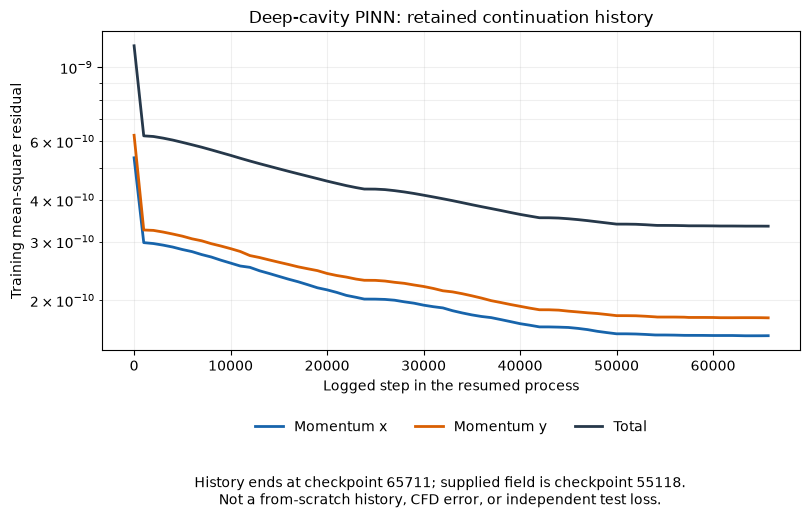

In [4]:
d=np.loadtxt(ROOT/'data/week13_deep_cavity/loss_continuation.dat')
assert d.shape==(74,3) and np.isfinite(d).all()
assert np.all(np.diff(d[:,0])>0) and np.all(d[:,1:]>0)
fig,ax=plt.subplots(figsize=(9,5.5))
for y,label,color in [(d[:,1],'Momentum x','#1764ab'),(d[:,2],'Momentum y','#d95f02'),(d[:,1:].sum(1),'Total','#26384a')]:
    ax.semilogy(d[:,0],y,label=label,color=color,lw=2)
ax.set(xlabel='Logged step in the resumed process',ylabel='Training mean-square residual',
       title='Deep-cavity PINN: retained continuation history')
ax.grid(alpha=.2,which='both')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.18),ncol=3,frameon=False)
fig.text(.5,.02,'History ends at checkpoint 65711; supplied field is checkpoint 55118.\nNot a from-scratch history, CFD error, or independent test loss.',ha='center',fontsize=10)
fig.subplots_adjust(bottom=.3)
out=ROOT/'results/week13_deep_cavity/loss_continuation.png'
fig.savefig(out,dpi=180,bbox_inches='tight')
print(out)
print('rows',len(d),'last total',d[-1,1:].sum())

plt.show()

## Build and train a small rectangular-cavity PINN on CPU
First follow a complete learning cycle: coordinates -> network -> streamfunction
lifting -> derivatives -> momentum residual -> gradient update -> held-out residual.
The two-output network represents streamfunction correction and pressure.
With $y=D\eta$, $u=\psi_\eta/D$, $v=-\psi_x$ and
$\Delta=\partial_{xx}+D^{-2}\partial_{\eta\eta}$.

The lifting imposes a smoothed lid, with $\delta_x=\sqrt{10^{-3}}$ and
$\delta_\eta=0.1$. Its correction vanishes quadratically at every wall. The
training mask is $m=(1-e^{-[x^2+(1-\eta)^2]/r^2})
(1-e^{-[(1-x)^2+(1-\eta)^2]/r^2})$, $r=0.01$.
It downweights corners; uniform collocation points are not removed. This differs
from an upstream exclusion radius 0.02. For D=2 the computational mask has
physical vertical extent 0.02, so changing D changes its physical footprint.
The short Adam experiment teaches the algorithm; use its printed residuals to
decide how much it learned. The longer archived experiment follows afterwards.
The default 200-step run is intentionally a budget-limited optimization example,
not a converged CFD substitute. Passing the continuity and wall checks only
verifies the representation; it does not establish momentum accuracy.

Architecture: Sequential(
  (0): Linear(in_features=2, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=20, bias=True)
  (3): Tanh()
  (4): Linear(in_features=20, out_features=2, bias=True)
)
{'initial_training_loss': 17.286661445704045, 'best_training_loss': 16.18883848753152, 'heldout_vector_RMS': 5.024861673620959, 'continuity_max': 3.552713678800501e-15}


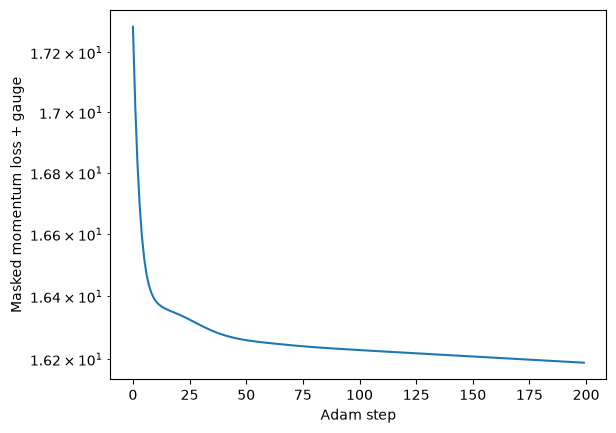

In [5]:
import copy, torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
torch.set_num_threads(1)
torch.manual_seed(13)
dtype=torch.float64
RE_CPU, D_CPU, STEPS_CPU = 100., 1., 200
cpu_pinn=nn.Sequential(nn.Linear(2,20),nn.Tanh(),nn.Linear(20,20),
                       nn.Tanh(),nn.Linear(20,2)).to(dtype=dtype)
def derivative(value, xy):
    return torch.autograd.grad(value,xy,torch.ones_like(value),create_graph=True)[0]
def cavity_fields(xy):
    raw=cpu_pinn(xy); x,e=xy[:,0:1],xy[:,1:2]
    lid=(1-torch.exp(-x*x/.001))*(1-torch.exp(-(1-x)**2/.001))
    psi=D_CPU*(e-1)*e**2*lid*torch.exp(-(1-e)**2/.01)
    psi=psi+(16*x*(1-x)*e*(1-e))**2*raw[:,0:1]
    g=derivative(psi,xy)
    return g[:,1:2]/D_CPU,-g[:,0:1],raw[:,1:2],psi
def cavity_residual(points):
    xy=points.detach().clone().requires_grad_(True)
    u,v,p,_=cavity_fields(xy)
    gu,gv,gp=[derivative(z,xy) for z in (u,v,p)]
    def lap(g):
        return derivative(g[:,0:1],xy)[:,0:1]+derivative(g[:,1:2],xy)[:,1:2]/D_CPU**2
    rx=u*gu[:,0:1]+v*gu[:,1:2]/D_CPU+gp[:,0:1]-lap(gu)/RE_CPU
    ry=u*gv[:,0:1]+v*gv[:,1:2]/D_CPU+gp[:,1:2]/D_CPU-lap(gv)/RE_CPU
    return rx,ry,gu[:,0:1]+gv[:,1:2]/D_CPU
train_xy=torch.rand(192,2,dtype=dtype)
heldout_xy=torch.rand(384,2,dtype=dtype)
x,e=train_xy[:,0:1],train_xy[:,1:2]
mask=(1-torch.exp(-(x*x+(1-e)**2)/.0001))*(1-torch.exp(-((1-x)**2+(1-e)**2)/.0001))
optimizer=torch.optim.Adam(cpu_pinn.parameters(),lr=1e-3)
cpu_history=[]; best_loss=float('inf'); best_state=None
for epoch in range(STEPS_CPU):
    optimizer.zero_grad()
    rx,ry,_=cavity_residual(train_xy)
    # Pressure gauge removes an arbitrary additive constant.
    loss=((mask*rx)**2+(mask*ry)**2).mean()+cpu_pinn(torch.tensor([[.5,.5]],dtype=dtype))[0,1]**2
    if loss.item()<best_loss:
        best_loss=loss.item(); best_state=copy.deepcopy(cpu_pinn.state_dict())
    loss.backward(); optimizer.step()
    cpu_history.append(loss.item())
cpu_pinn.load_state_dict(best_state)
rx,ry,div=cavity_residual(heldout_xy)
print('Architecture:',cpu_pinn)
print({'initial_training_loss':cpu_history[0],'best_training_loss':best_loss,
       'heldout_vector_RMS':float(torch.sqrt((rx**2+ry**2).mean()).detach()),
       'continuity_max':float(div.detach().abs().max())})
assert np.isfinite(cpu_history).all() and best_loss<cpu_history[0]
assert float(div.detach().abs().max())<1e-9
fig,ax=plt.subplots(); ax.semilogy(cpu_history); ax.set(xlabel='Adam step',ylabel='Masked momentum loss + gauge'); plt.show()

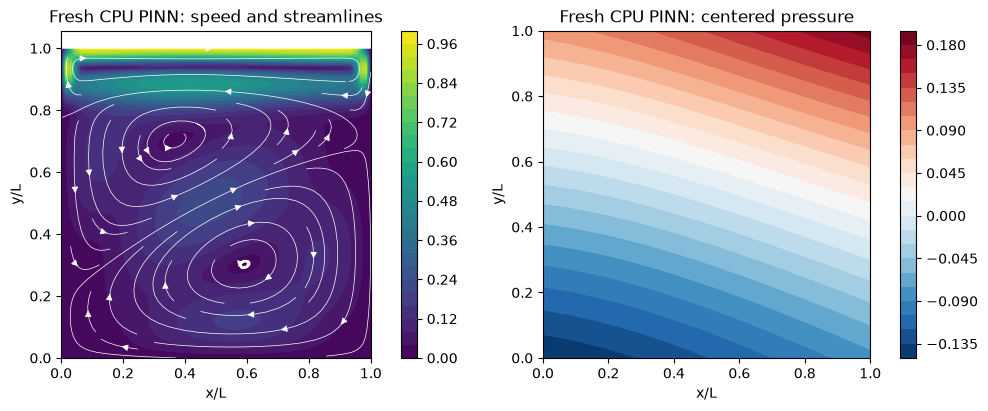

In [6]:
# Evaluate the learned field on an independent grid. Streamlines use u and v.
gx=np.linspace(0,1,65); ge=np.linspace(0,1,65); XX,EE=np.meshgrid(gx,ge)
xy=torch.tensor(np.c_[XX.ravel(),EE.ravel()],dtype=dtype,requires_grad=True)
uu,vv,pp,_=cavity_fields(xy)
uu,vv,pp=[q.detach().numpy().reshape(65,65) for q in (uu,vv,pp)]
fig,axs=plt.subplots(1,2,figsize=(10,4),layout='constrained')
im=axs[0].contourf(gx,D_CPU*ge,np.hypot(uu,vv),32,cmap='viridis')
axs[0].streamplot(gx,D_CPU*ge,uu,vv,color='white',density=.7,linewidth=.5)
fig.colorbar(im,ax=axs[0]); axs[0].set_title('Fresh CPU PINN: speed and streamlines')
im=axs[1].contourf(gx,D_CPU*ge,pp-pp.mean(),32,cmap='RdBu_r')
fig.colorbar(im,ax=axs[1]); axs[1].set_title('Fresh CPU PINN: centered pressure')
for ax in axs: ax.set(xlabel='x/L',ylabel='y/L',aspect='equal')
plt.show()
# Exact wall transform is checked independently of training quality.
expected=(1-np.exp(-gx**2/.001))*(1-np.exp(-(1-gx)**2/.001))
np.testing.assert_allclose(uu[-1],expected,atol=1e-10)
assert max(abs(vv).take([0,-1],axis=0).max(),abs(uu[0]).max(),abs(uu[:,[0,-1]]).max())<1e-9

### Why the optimizer and residual convention matter
SSBroyden2 is a self-scaled Broyden quasi-Newton variant. With inverse Hessian
estimate $H_k$, its search step is $d_k=-H_k\nabla L_k$ and
$\theta_{k+1}=\theta_k+\alpha_k d_k$. A line search selects $\alpha_k$;
self-scaling modifies the full inverse-Hessian update, constrained by the
secant relation $H_{k+1}y_k=s_k$. Full storage costs $O(P^2)$ for P parameters.
Adam in the small experiment above is a separate, explicitly visible optimizer.
See [Urbán, Stefanou & Pons, JCP 523 (2025), 113656](https://arxiv.org/abs/2405.04230)
and [Kiyani et al.](https://arxiv.org/abs/2501.16371) for the self-scaling rules.

Both full and corner diagnostics below use
$R_S=\sqrt{\langle r_x^2+r_y^2\rangle_S}$. Historical corner-history values
stored as component RMS are multiplied by $\sqrt2$ for display. A narrow lid
transition increases second velocity derivatives, and the viscous term scales
as $1/Re$. This can make Re=100 residuals larger than Re=400 despite better
velocity agreement. Residual magnitude and field error answer different questions.
The 65x65 teaching CFD reference has discretization error and a discontinuous
lid; comparison with a smoothed-lid PINN is an approximate diagnostic.

## 1. Physical-coordinate audit

The network sees `(x, eta)` on a unit square, while physical `y/L = D eta`. Therefore `∂y = D⁻¹∂eta`, `u = D⁻¹∂eta psi`, and every second y derivative carries `D⁻²`. The `D=1` reduction is a required implementation check.


In [7]:
records=[]
for Re,D in CASES:
    folder=RESULT/f're{Re}-d{D}'
    audit=json.loads((folder/'audit.json').read_text())
    history=[json.loads(line) for line in (folder/'optimizer-history.jsonl').read_text().splitlines() if line]
    files={p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in folder.iterdir() if p.is_file()}
    records.append(dict(Re=Re,D=D,folder=folder,audit=audit,history=history,hashes=files))
print('Loaded four immutable evidence packages.')


Loaded four immutable evidence packages.


## 2. Training loss is not the verdict

Plot the masked collocation residual beside independent full-domain and corner-band residuals. Adam occupies steps 1–1000; SSBroyden2 continues the same weights. This is an optimizer trajectory, not a matched optimizer-comparison claim.


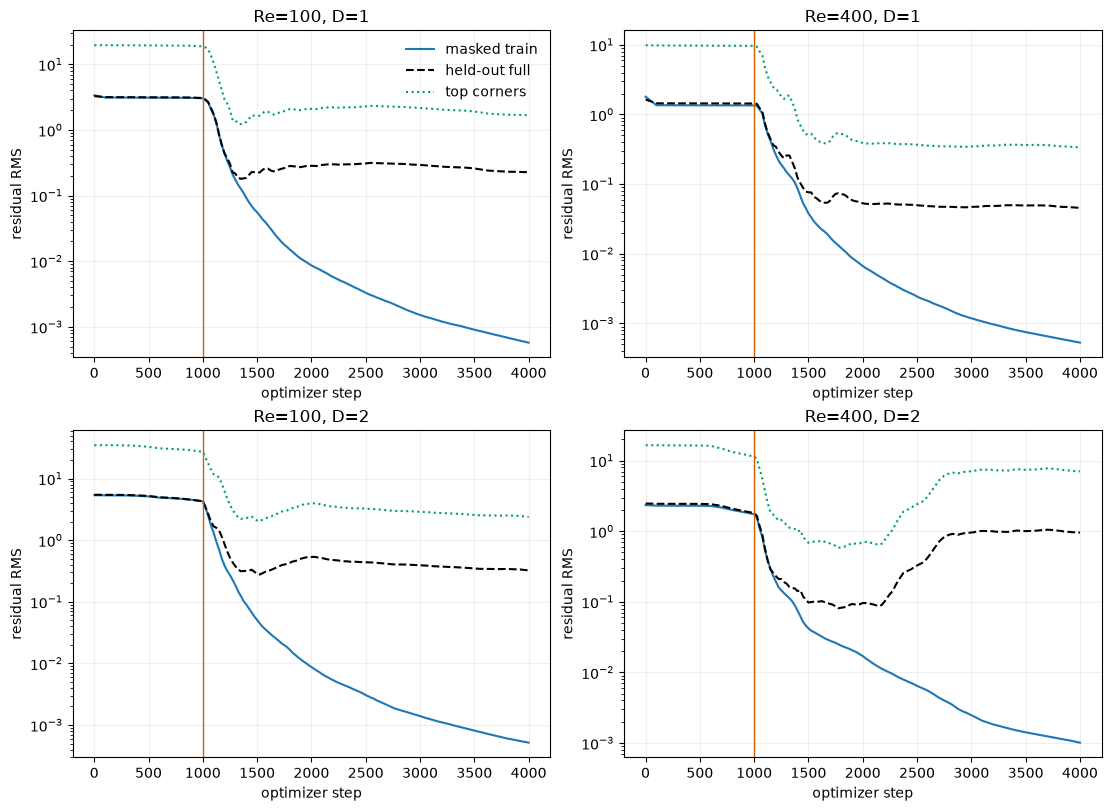

In [8]:
fig,axs=plt.subplots(2,2,figsize=(11,8),constrained_layout=True)
for ax,r in zip(axs.ravel(),records):
    rows=list({q['global_step']:q for q in r['history']}.values()); rows.sort(key=lambda q:q['global_step'])
    steps=[q['global_step'] for q in rows]
    ax.semilogy(steps,[np.sqrt(q['train_rx_mse']+q['train_ry_mse']) for q in rows],label='masked train')
    ax.semilogy(steps,[q['heldout_momentum_rms'] for q in rows],'k--',label='held-out full')
    ax.semilogy(steps,[np.sqrt(2)*q['top_corner_momentum_rms'] for q in rows],':',color='#009E73',label='top corners')
    ax.axvline(1000,color='#D55E00',lw=1); ax.set(title=f"Re={r['Re']}, D={r['D']}",xlabel='optimizer step',ylabel='residual RMS'); ax.grid(alpha=.2)
axs[0,0].legend(frameon=False); plt.show()


## 3. Independent evidence table

The square cases are judged against frozen CFD gates. Deep cases report residuals and topology only; `n/a` is the scientifically correct result when the matched field is unavailable.


In [9]:
rows=[]
for r in records:
    a=r['audit']; z=a['independent_residual']; c=a.get('cfd_comparison')
    rows.append((r['Re'],r['D'],np.hypot(z['momentum_x_rms'],z['momentum_y_rms']),
                 np.hypot(z['top_corner_momentum_x_rms'],z['top_corner_momentum_y_rms']),
                 max(max(w.values()) for w in a['wall_error'].values()),None if c is None else c['all_pass'],a['claim_status']))
print(f"{'Re':>5} {'D':>3} {'R_full':>11} {'R_corner':>11} {'wall max':>11} {'CFD gates':>10}  status")
for row in rows: print(f"{row[0]:5d} {row[1]:3d} {row[2]:11.3e} {row[3]:11.3e} {row[4]:11.3e} {str(row[5]):>10}  {row[6]}")


   Re   D      R_full    R_corner    wall max  CFD gates  status
  100   1   4.955e-01   3.440e+00   0.000e+00       True  field-qualified-square-case
  400   1   4.745e-02   3.354e-01   0.000e+00       True  field-qualified-square-case
  100   2   3.705e-01   2.720e+00   0.000e+00       None  residual-audited-no-field-reference
  400   2   1.305e-01   9.489e-01   0.000e+00       None  residual-audited-no-field-reference


## 4. Geometry-faithful fields

These are retained Unity renders. A contour is evidence of what the model represents, not proof that the representation is correct. Use the table above to determine which claims are actually available.


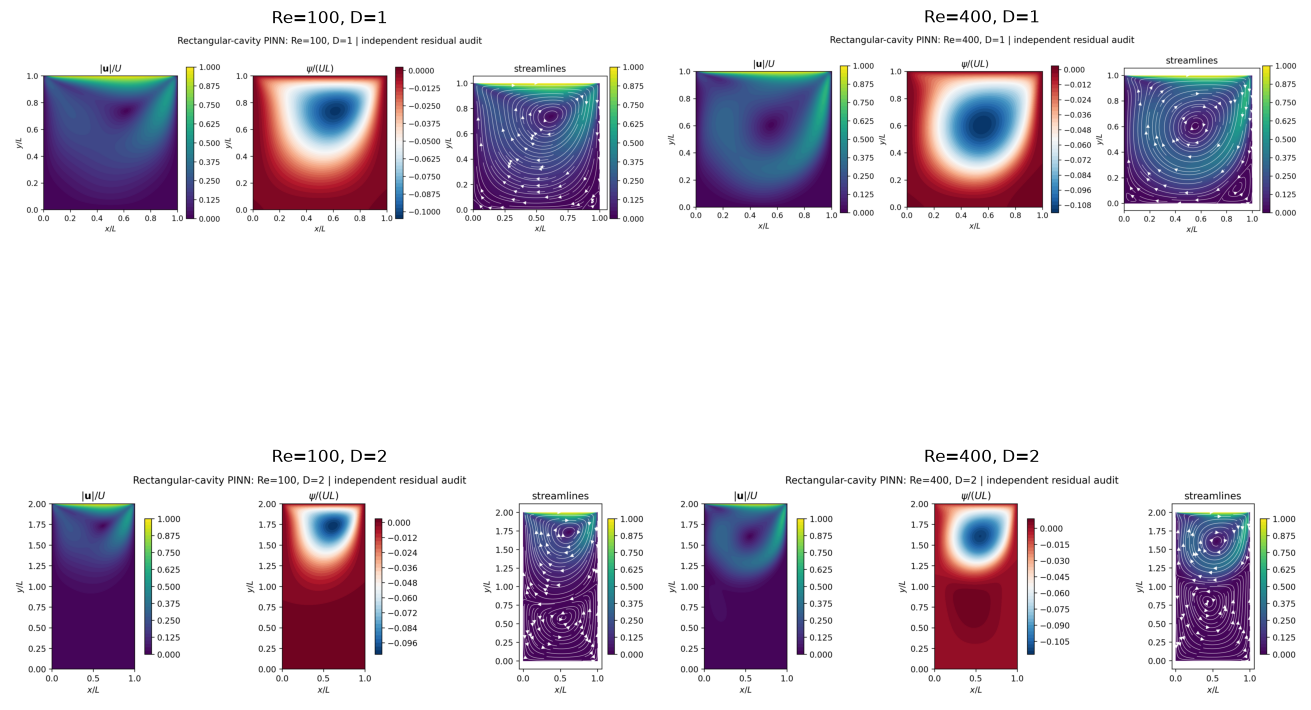

In [10]:
fig,axs=plt.subplots(2,2,figsize=(13,9),constrained_layout=True)
for ax,r in zip(axs.ravel(),records):
    ax.imshow(plt.imread(r['folder']/'fields.png')); ax.axis('off'); ax.set_title(f"Re={r['Re']}, D={r['D']}")
plt.show()


## 5. Research decision

Answer before extending the run:

1. Did the held-out full residual fall with the masked training residual?
2. Did the corner band improve, stagnate or deteriorate?
3. Which square cases pass every frozen CFD gate?
4. Which deep-case statements remain hypotheses because no matched raw field exists?
5. What factorial comparison would distinguish representation from optimizer, budget and lid regularization?

The next paper-quality experiment must compare primitive/FOSLS and streamfunction representations at matched physics, capacity and residual-evaluation budget, with several preregistered seeds. Failed seeds remain in the denominator.
